In [2]:
import pandas as pd

# Read three CSV files into separate DataFrames
deb = pd.read_csv('../data/tests_results/classification_gaia_deb.csv')
ogle = pd.read_csv('../data/tests_results/classification_gaia_ogle.csv')
wumacat = pd.read_csv('../data/tests_results/classification_tess_WUMaCat.csv')

In [4]:
wumacat.columns

Index(['name', 'gaia', 'binary_tess_res', 'spot_tess_res', 'binary_tess_vit',
       'spot_tess_vit', 'binary_gaia_res', 'spot_gaia_res', 'binary_gaia_vit',
       'spot_gaia_vit', 'real_spot'],
      dtype='object')

In [3]:
def find_consistent_objects(df, col):
    """
    Finds objects with consistent 'det' values in the specified column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        col (str): Name of the column to check for consistency.

    Returns:
        pd.DataFrame: A DataFrame containing the names of objects that have 'det' values
                      in the specified column.
    """
    consistent_objects = df[df[col] == 'det']['name']
    return consistent_objects

consistent_binary_res_wuma = find_consistent_objects(wumacat, 'binary_gaia_res')
consistent_binary_vit_wuma = find_consistent_objects(wumacat, 'binary_gaia_vit')


print("Consistent objects in deb binary_tess:", consistent_binary_res_wuma.tolist())
print("Consistent objects in deb binary_gaia:", consistent_binary_vit_wuma.tolist())


Consistent objects in deb binary_tess: ['AQ Psc', 'FT Lup', 'TYC 2675-663-1']
Consistent objects in deb binary_gaia: ['AH Aur', 'BX And', 'FT Lup', 'QW Gem', 'SX Crv', 'TYC 2675-663-1', 'V592 Per', 'V870 Ara']


In [6]:
consistent_binary_res_wuma = consistent_binary_res_wuma.str.strip()
consistent_binary_vit_wuma = consistent_binary_vit_wuma.str.strip()
consistent_binary_res_wuma

12            AQ Psc
38            FT Lup
62    TYC 2675-663-1
Name: name, dtype: object

Light curve saved to AH Aur_light_curve.png
Light curve saved to BX And_light_curve.png
Light curve saved to FT Lup_light_curve.png
Light curve saved to QW Gem_light_curve.png
Light curve saved to SX Crv_light_curve.png
Light curve saved to TYC 2675-663-1_light_curve.png
Light curve saved to V592 Per_light_curve.png
Light curve saved to V870 Ara_light_curve.png


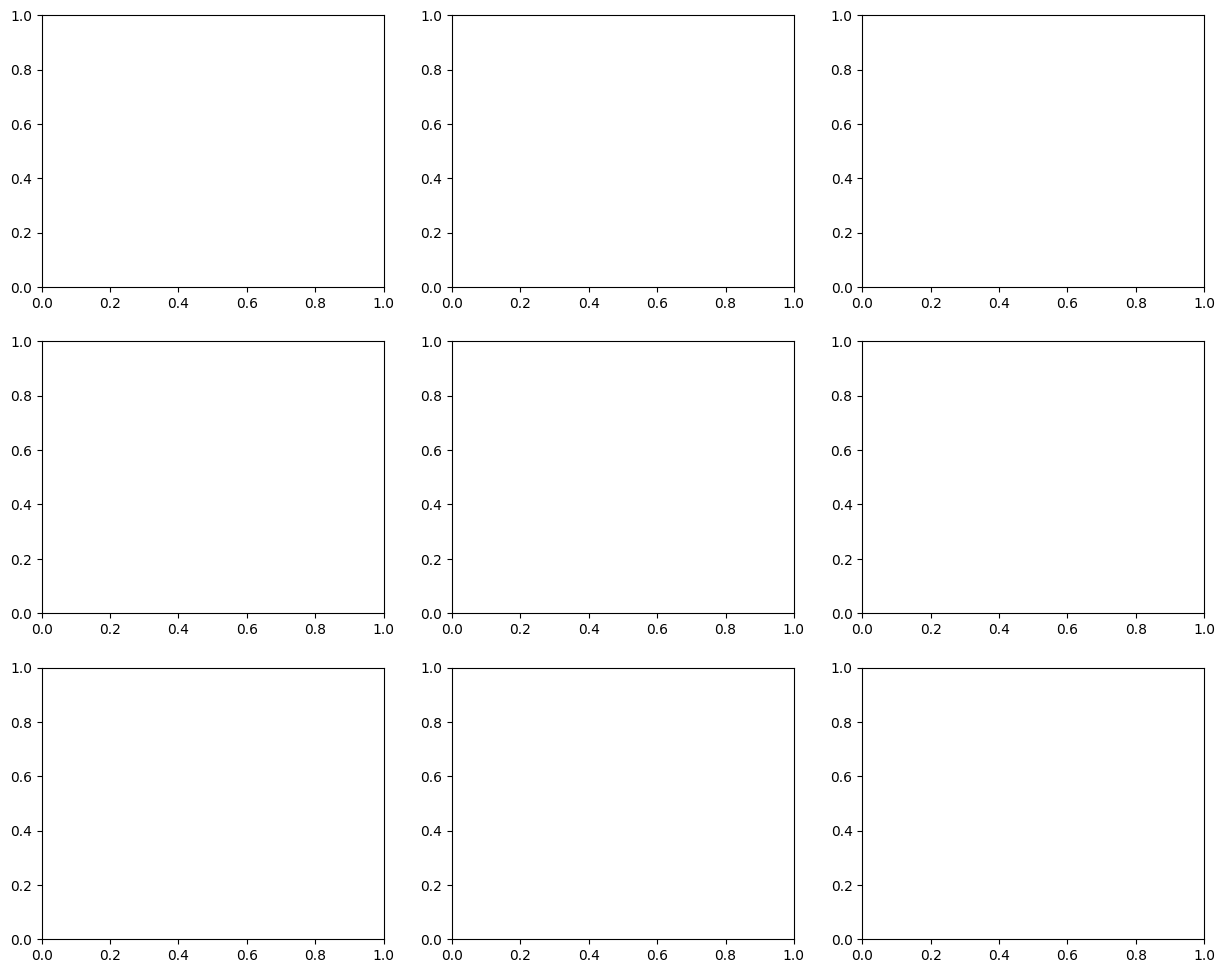

In [5]:
import numpy as np
from astropy.io import ascii
import os

import matplotlib.pyplot as plt

def plot_light_curves(object_list, directory="../data/lc/lc_wuma_gaia/"):
    """
    Plots light curves for a list of objects from CSV files in a directory.

    Args:
        object_list (list): A list of object names.
        directory (str): The directory containing the CSV files.
    """
    num_objects = len(object_list)
    if num_objects == 0:
        print("No objects to plot.")
        return

    # Determine the number of rows and columns for the subplots
    num_cols = min(3, num_objects)  # Up to 3 plots per row
    num_rows = (num_objects + num_cols - 1) // num_cols  # Calculate the number of rows needed

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # If there's only one subplot, axes is not an array
    if num_objects == 1:
        axes = [axes]
    elif num_rows == 1 or num_cols ==1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()


    for i, obj_name in enumerate(object_list):
        try:
            # Load the light curve data from CSV
            # Construct the file path
            # Construct the file path
            files = os.listdir(directory)
            matching_files = [file for file in files if obj_name in file and file.endswith(".ecvs")]

            if not matching_files:
                print(f"Light curve file not found for {obj_name}")
                continue

            file_path = os.path.join(directory, matching_files[0])
            lc_table = ascii.read(file_path, format='ecsv')
            lc_df = lc_table.to_pandas()

            # Extract time and magnitude
            time = lc_df['Phase']
            mag = lc_df['norm_FG']

            # Create a new figure and axes for each object
            fig, ax = plt.subplots(figsize=(8, 6))

            # Plot the light curve
            ax.plot(time, mag, 'o', markersize=2)
            ax.set_xlabel("Phase")
            ax.set_ylabel("Normalized Flux")
            ax.set_title(obj_name)
            ax.set_xlim(-0.05, 1.05)
            ax.tick_params(direction='in', which='both', top=True, right=True)
            # Save the figure to a file
            filename = f"{obj_name}_light_curve.png"
            plt.tight_layout()
            plt.savefig(filename)
            plt.close(fig)  # Close the figure to free memory

            print(f"Light curve saved to {filename}")

        except FileNotFoundError:
            print(f"Light curve file not found for {obj_name}")
        except Exception as e:
            print(f"Error plotting {obj_name}: {e}")

# Example usage:
plot_light_curves(consistent_binary_vit_wuma.tolist())

In [9]:
import numpy as np
from astropy.io import ascii
import os

import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

def plot_light_curves(object_list, directories=["../data/lc/lc_wuma_gaia/", "../data/lc/"]):
    """
    Plots two light curves for each object on the same graph, searching in a list of directories.

    Args:
        object_list (list): A list of object names.
        directories (list): A list of directories containing the CSV files.
    """
    num_objects = len(object_list)
    if num_objects == 0:
        print("No objects to plot.")
        return

    for obj_name in object_list:
        # Initialize lists to store light curve data
        ph1, flux1, ph2, flux2 = None, None, None, None
        dir1_found, dir2_found = False, False

        # Search for the first light curve
        for directory in directories:
            try:
                files = os.listdir(directory)
                matching_files = [file for file in files if obj_name in file and file.endswith(".ecvs")]

                if not matching_files:
                    print(f"Light curve file not found for {obj_name} in {directory}")
                    continue

                file_path = os.path.join(directory, matching_files[0])
                lc_table = ascii.read(file_path, format='ecsv')
                lc_df = lc_table.to_pandas()

                ph1 = lc_df['Phase']
                flux1 = lc_df['norm_FG']
                dir1_found = True
                break  # Break after finding the first light curve

            except FileNotFoundError:
                print(f"Light curve file not found for {obj_name} in {directory}")
            except Exception as e:
                print(f"Error reading {obj_name} from {directory}: {e}")

        # Search for the second light curve (if needed, modify search criteria accordingly)
        for directory in directories:
            try:
                files = os.listdir(directory)
                matching_files = [file for file in files if obj_name in file and file.endswith(".csv")]

                if not matching_files:
                    print(f"Second light curve file not found for {obj_name} in {directory}")
                    continue

                file_path = os.path.join(directory, matching_files[0])
                lc_table = ascii.read(file_path)
                lc_df = lc_table.to_pandas()

                ph2 = lc_df['phase']  # Adjust column names as needed
                flux2 = lc_df['normalized_flux']  # Adjust column names as needed
                
                
                bins=100
                ph=binned_statistic(ph2,ph2,statistic='median',bins=bins,range=[-0.5/bins,1+0.5/bins])[0]
                fl=binned_statistic(ph2,flux2,statistic='median',bins=bins,range=[-0.5/bins,1+0.5/bins])[0]
                
                dir2_found = True
                break  # Break after finding the second light curve

            except FileNotFoundError:
                print(f"Second light curve file not found for {obj_name} in {directory}")
            except Exception as e:
                print(f"Error reading second light curve for {obj_name} from {directory}: {e}")

        # Plot both light curves on the same subplot if both are found
        if dir1_found and dir2_found:
            fig, ax = plt.subplots(figsize=(8, 6))

            if obj_name == 'BX And':
                ph1 = ph1 - 0.07
            if obj_name == 'FT Lup':
                ph1 = ph1 - 0.05
            if obj_name == 'SX Crv':
                ph1 = ph1 - 0.02
            ax.plot(ph1, flux1, 'o', markersize=5, label='Gaia G')
            ax.plot(ph, fl, 'o', markersize=3, label='TESS')

            ax.set_xlabel("Phase")
            ax.set_ylabel("Normalized Flux")
            ax.set_title(obj_name)
            ax.set_xlim(-0.05, 1.05)
            ax.tick_params(direction='in', which='both', top=True, right=True)
            ax.legend()

            filename = f"{obj_name}_combined_light_curve.png"
            plt.tight_layout()
            plt.savefig(filename)
            plt.close(fig)
            print(f"Combined light curve saved to {filename}")
        else:
            print(f"Could not find both light curves for {obj_name}")

# Example usage:
directories_list = ["../data/lc/lc_wuma_gaia/", "/Users/wera/Max_astro/Slovakia/WUMaCat/data/wuma_lcs"]  # Add your additional directories here
plot_light_curves(consistent_binary_res_wuma.tolist(), directories=directories_list)


Second light curve file not found for AQ Psc in ../data/lc/lc_wuma_gaia/
Combined light curve saved to AQ Psc_combined_light_curve.png
Second light curve file not found for FT Lup in ../data/lc/lc_wuma_gaia/
Combined light curve saved to FT Lup_combined_light_curve.png
Second light curve file not found for TYC 2675-663-1 in ../data/lc/lc_wuma_gaia/
Combined light curve saved to TYC 2675-663-1_combined_light_curve.png
